---
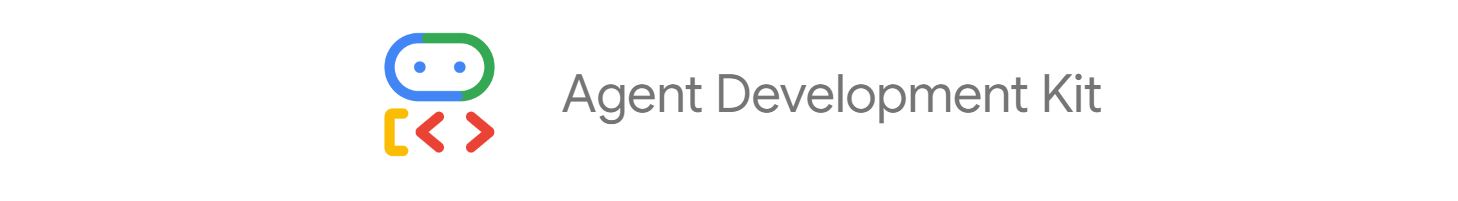

---

# Using Different Models with ADK
The Agent Development Kit (ADK) is designed for flexibility, allowing you to integrate various Large Language Models (LLMs) into your agents. While the setup for Google Gemini models is covered in the [Setup Foundation Models](https://google.github.io/adk-docs/get-started/installation/) guide, this page details how to leverage Gemini effectively and integrate other popular models, including those hosted externally or running locally.

ADK primarily uses two mechanisms for model integration:

1. **Direct String / Registry:** For models tightly integrated with Google Cloud (like Gemini models accessed via Google AI Studio or Vertex AI) or models hosted on Vertex AI endpoints. You typically provide the model name or endpoint resource string directly to the `LlmAgent`. ADK's internal registry resolves this string to the appropriate backend client, often utilizing the `google-genai` library.

1. **Wrapper Classes:** For broader compatibility, especially with models outside the Google ecosystem or those requiring specific client configurations (like models accessed via LiteLLM). You instantiate a specific wrapper class (e.g., `LiteLlm`) and pass this object as the `model` parameter to your `LlmAgent`.

----

The following sections guide you through using these methods based on your needs.

## Using Google Gemini Models
This section covers authenticating with Google's Gemini models, either through Google AI Studio for rapid development or Google Cloud Vertex AI for enterprise applications. This is the most direct way to use Google's flagship models within ADK.

**Integration Method:** Once you are authenticated using one of the below methods, you can pass the model's identifier string directly to the `model` parameter of `LlmAgent`.

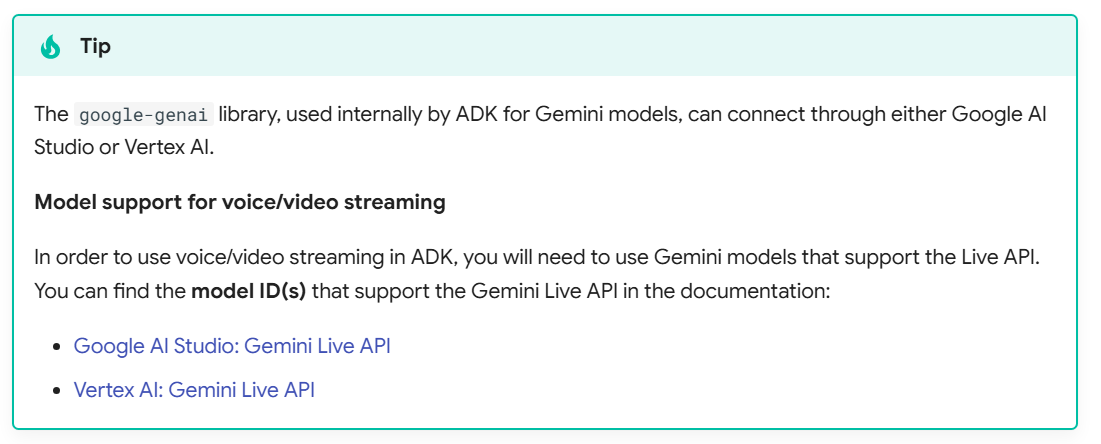

- **Google AI Studio:** `Gemini Live API` [Learn more](https://ai.google.dev/gemini-api/docs/models#live-api) <br><br> 
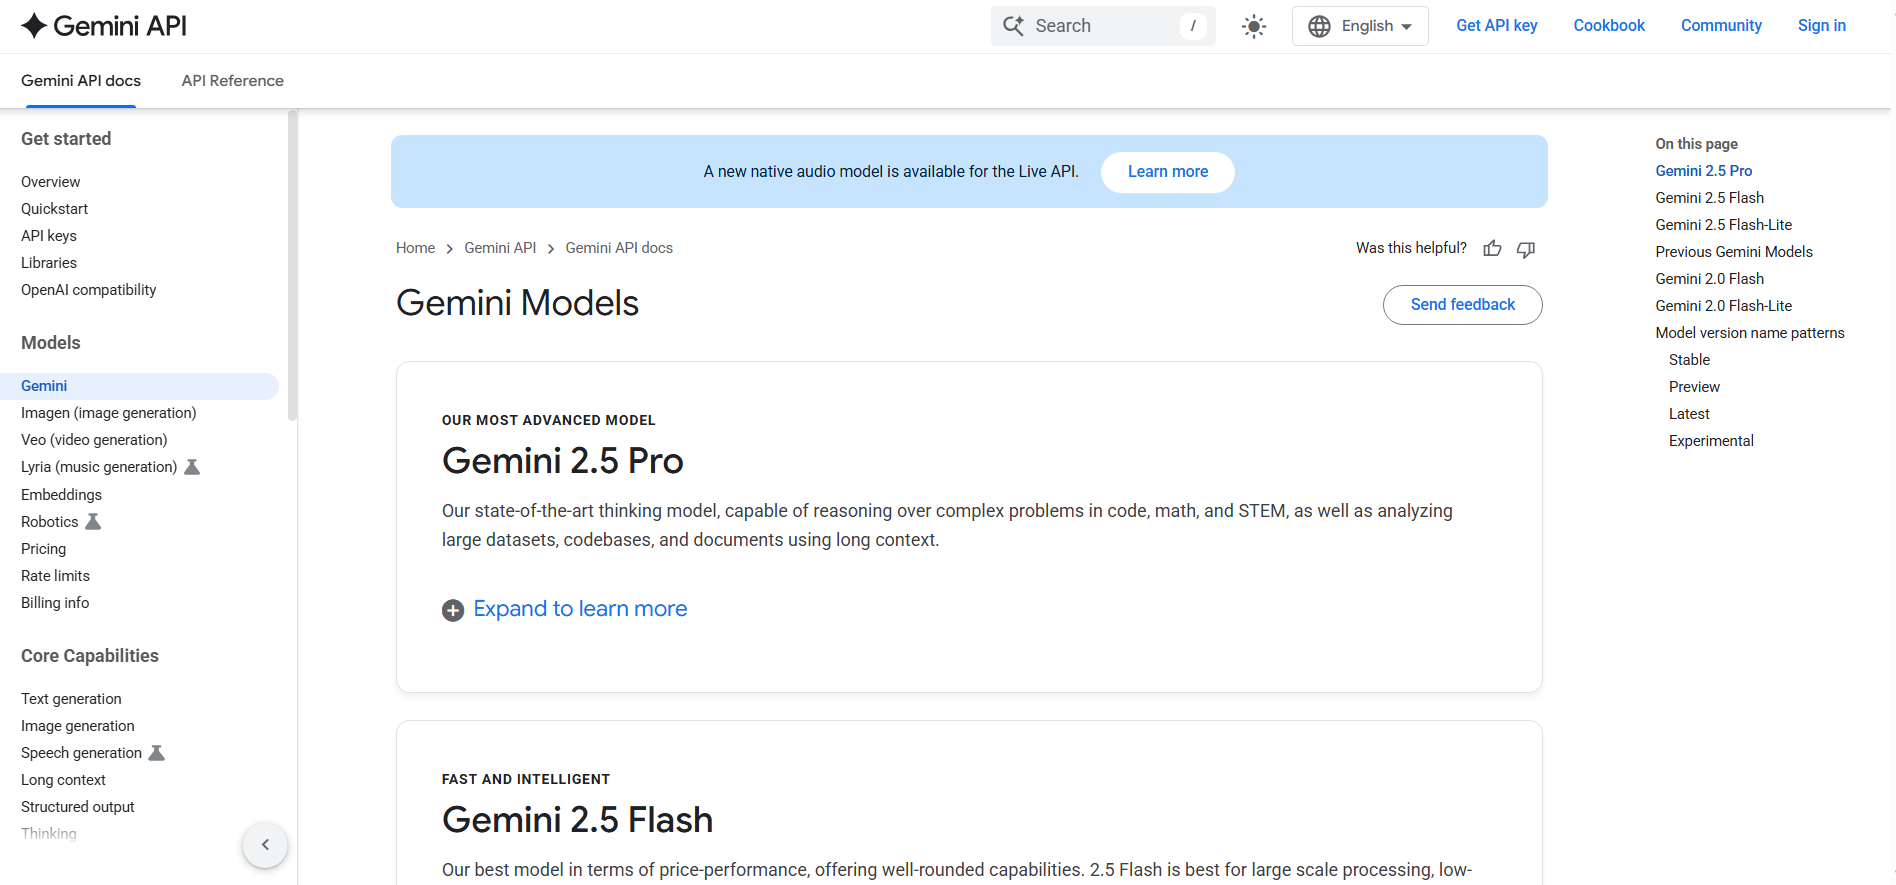

- **Vertex AI:** `Gemini Live API` [Learn more](https://cloud.google.com/vertex-ai/generative-ai/docs/live-api) <br><br>
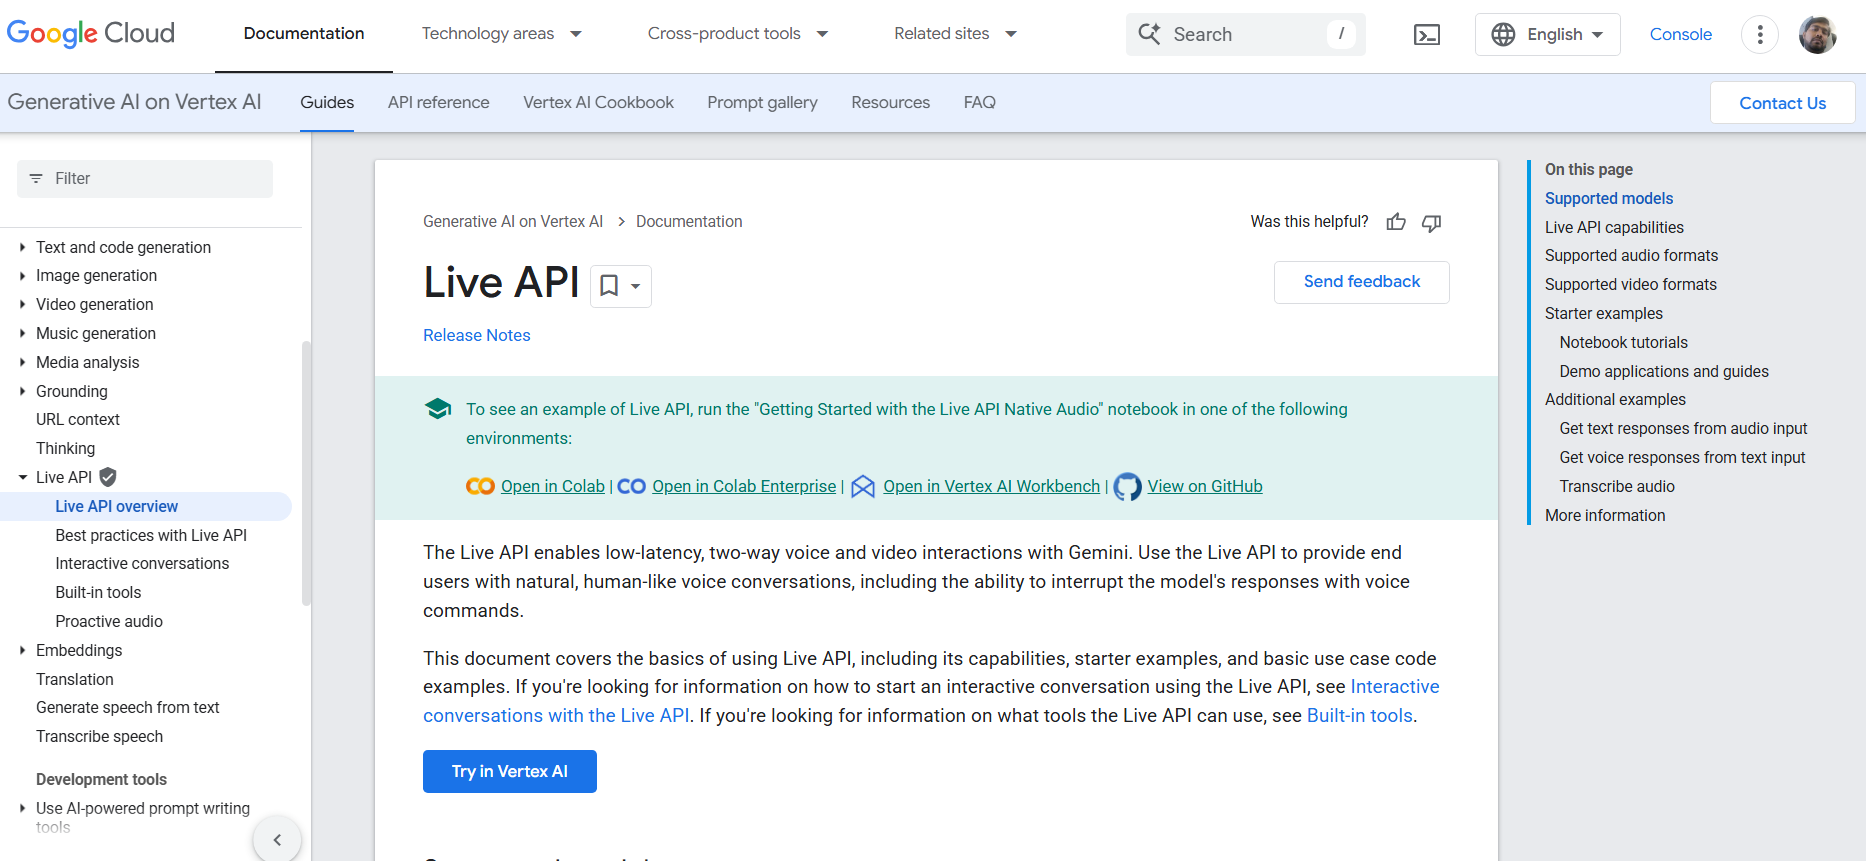

    - **`Try in Vertex AI`** <br><br> 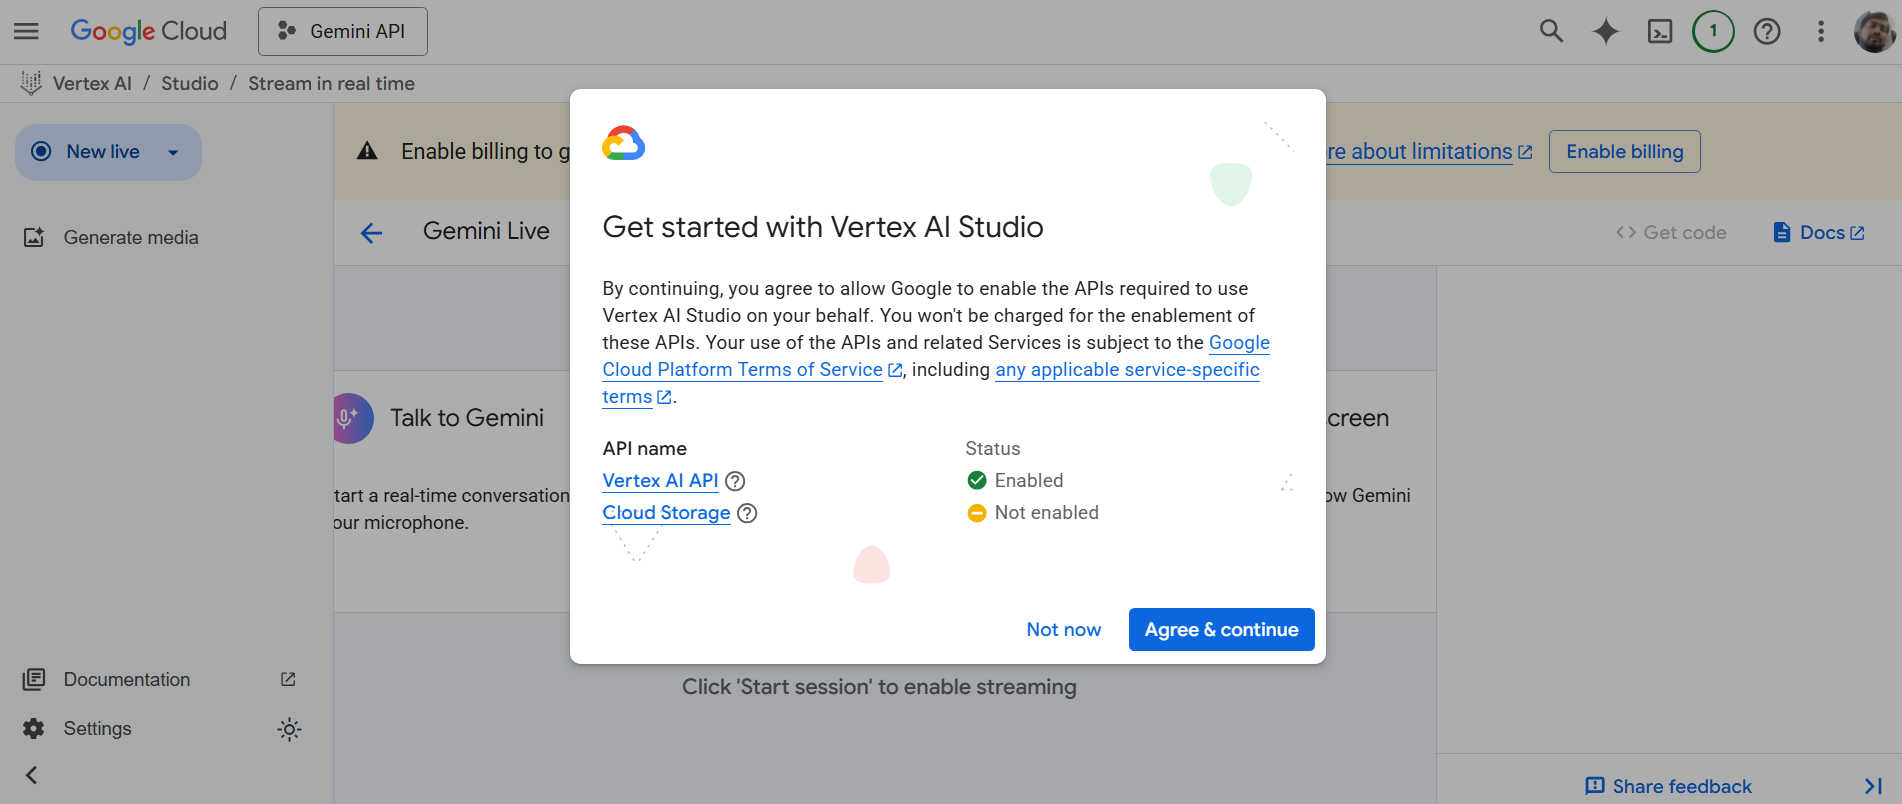 <br> 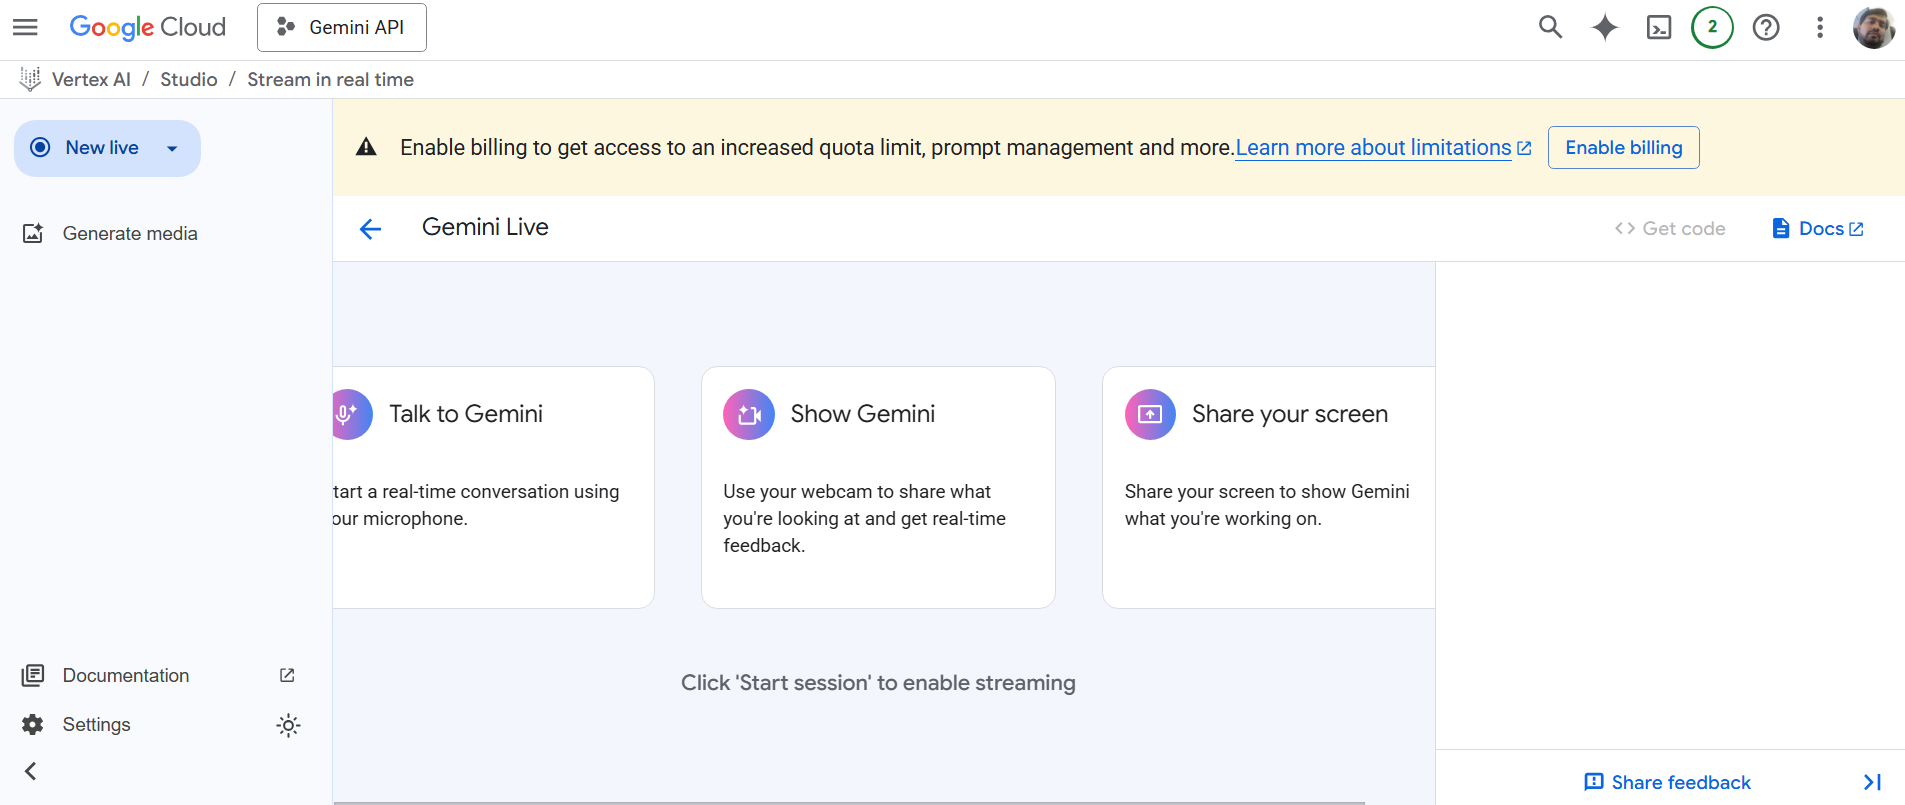

---

### Google AI Studio
This is the simplest method and is recommended for getting started quickly.

- **Authentication Method:** API Key

- **Setup:**
    - **Get an API key:** Obtain your key from [Google AI Studio](https://aistudio.google.com/api-keys). <br><br>
      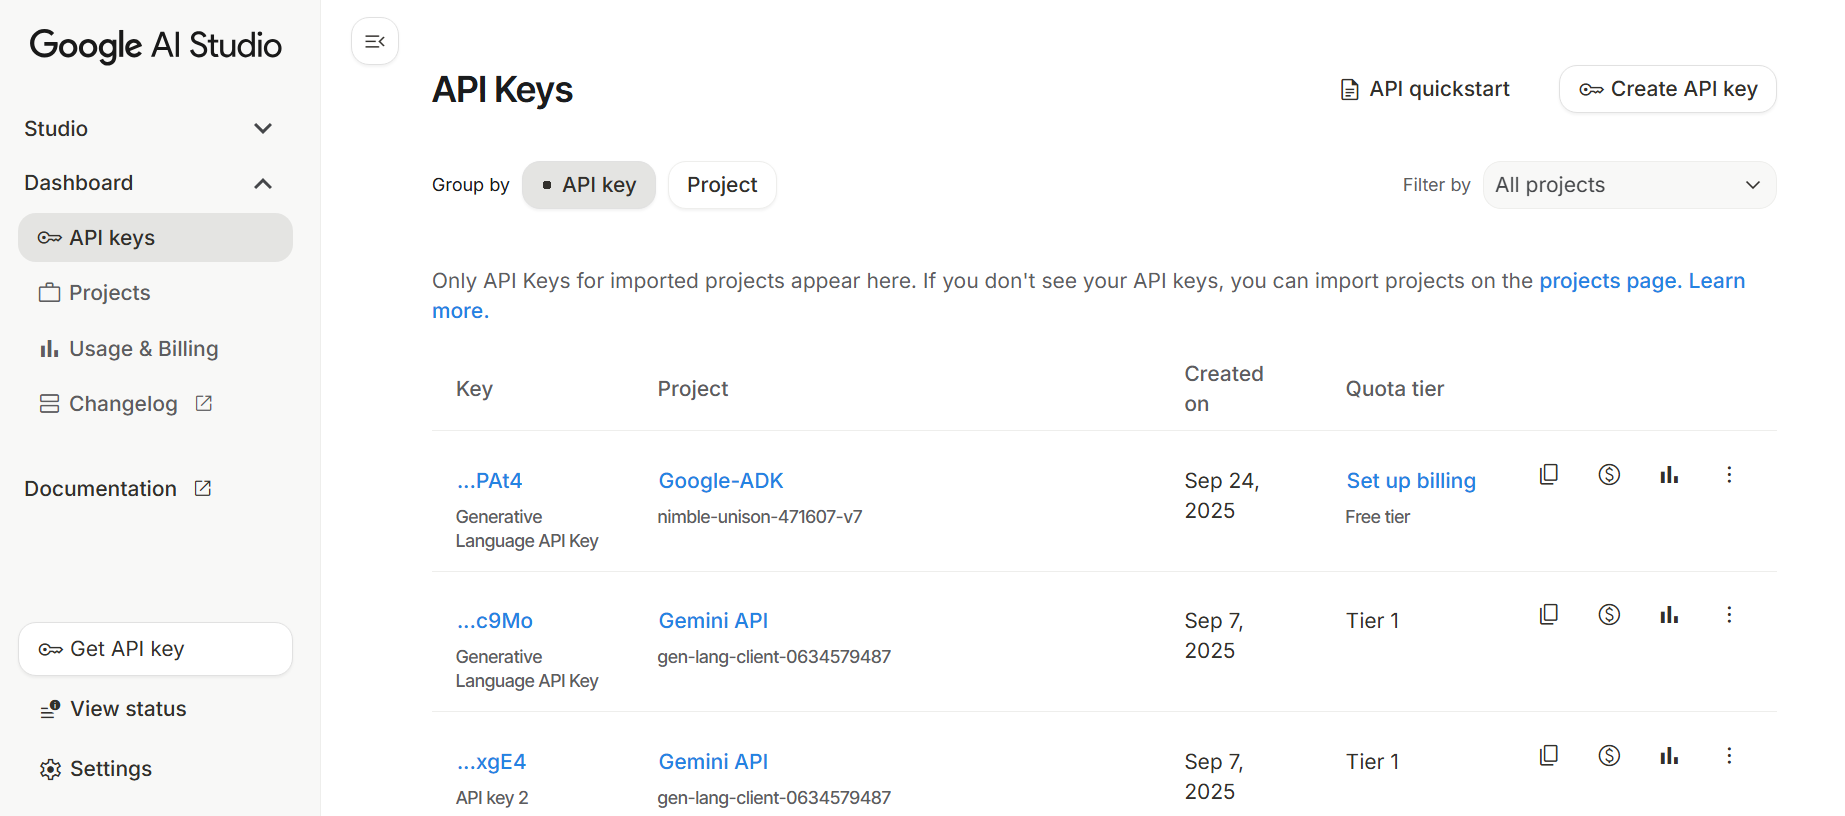

    - **Set environment variables:** Create a .env file (Python) or .properties (Java) in your project's root directory and add the following lines. ADK will automatically load this file. <br>
    **.env**
      ```bash
      export GOOGLE_API_KEY="YOUR_GOOGLE_API_KEY"
      export GOOGLE_GENAI_USE_VERTEXAI=FALSE
      ```
      (or)
      Pass these variables during the model initialization via the `Client` (see example below).

- **Models:** Find all available models on the [Google AI for Developers site](https://ai.google.dev/gemini-api/docs/models). <br><br>
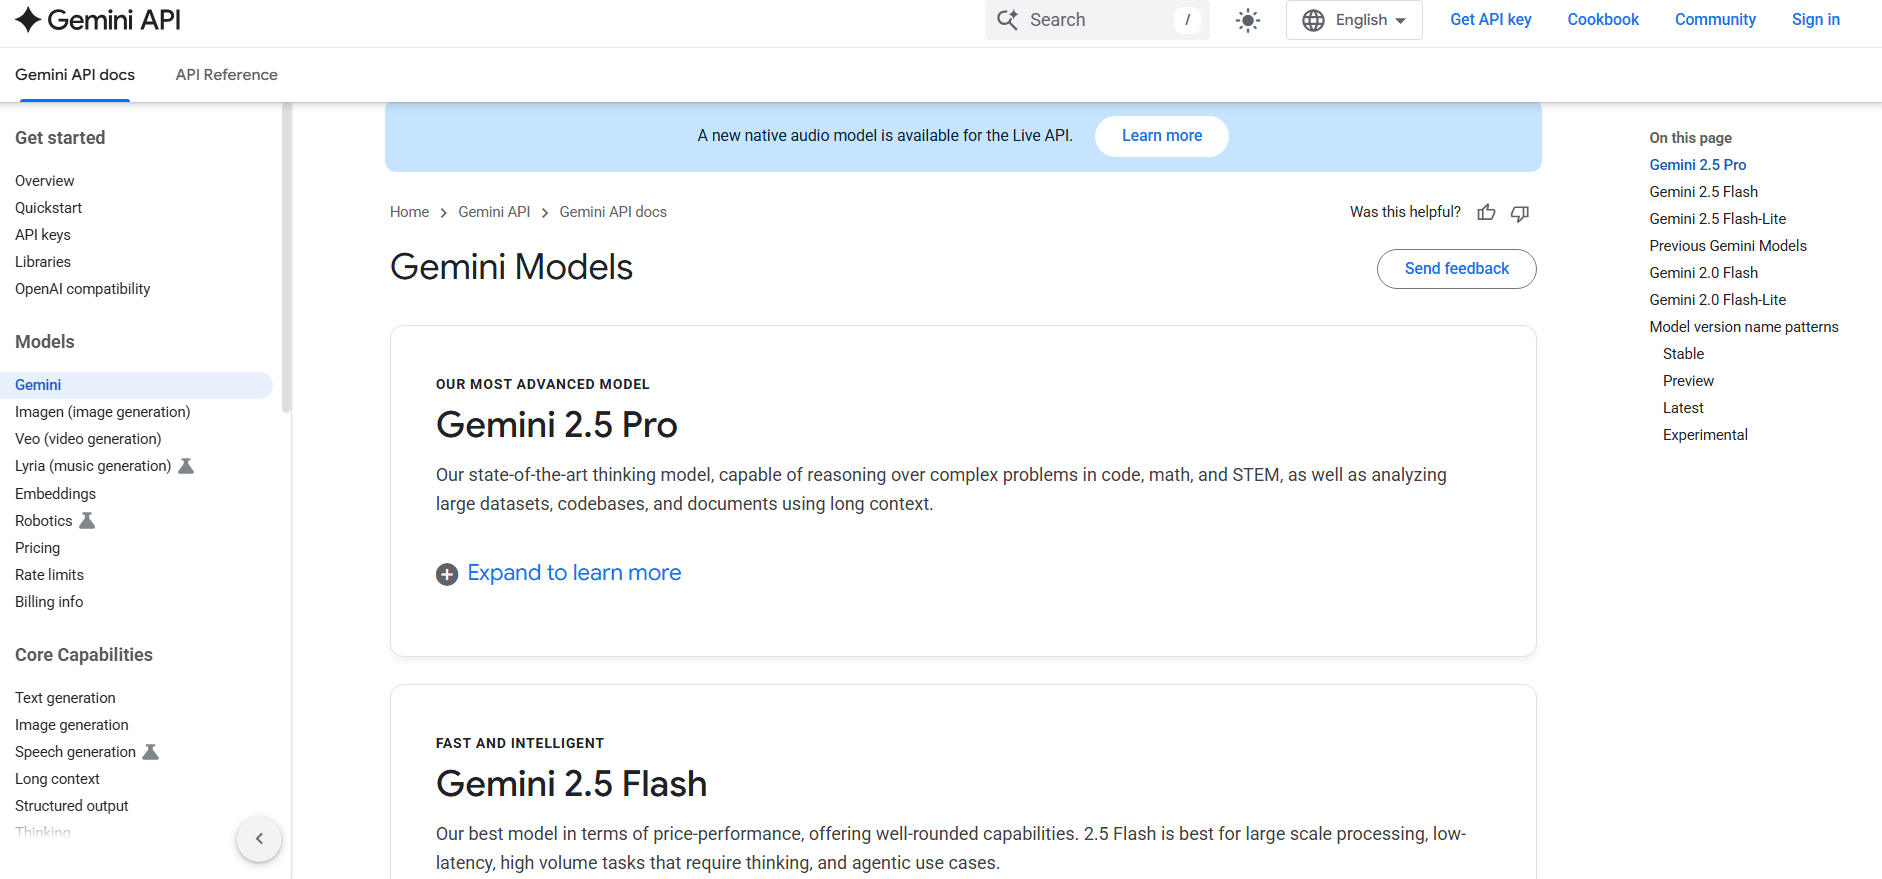

---

### Google Cloud Vertex AI
For scalable and production-oriented use cases, Vertex AI is the recommended platform. Gemini on Vertex AI supports enterprise-grade features, security, and compliance controls. Based on your development environment and usecase, choose one of the below methods to authenticate.

**Pre-requisites:** A Google Cloud Project with [Vertex AI enabled](https://console.cloud.google.com/). <br><br> 
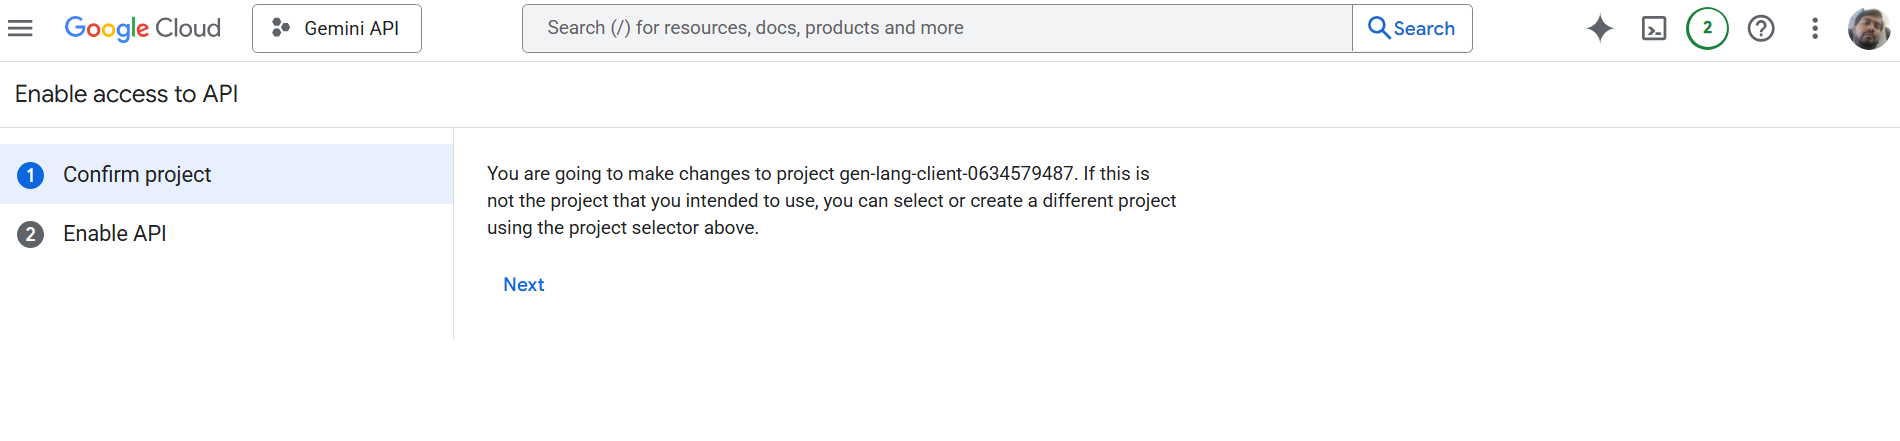 <br><br> 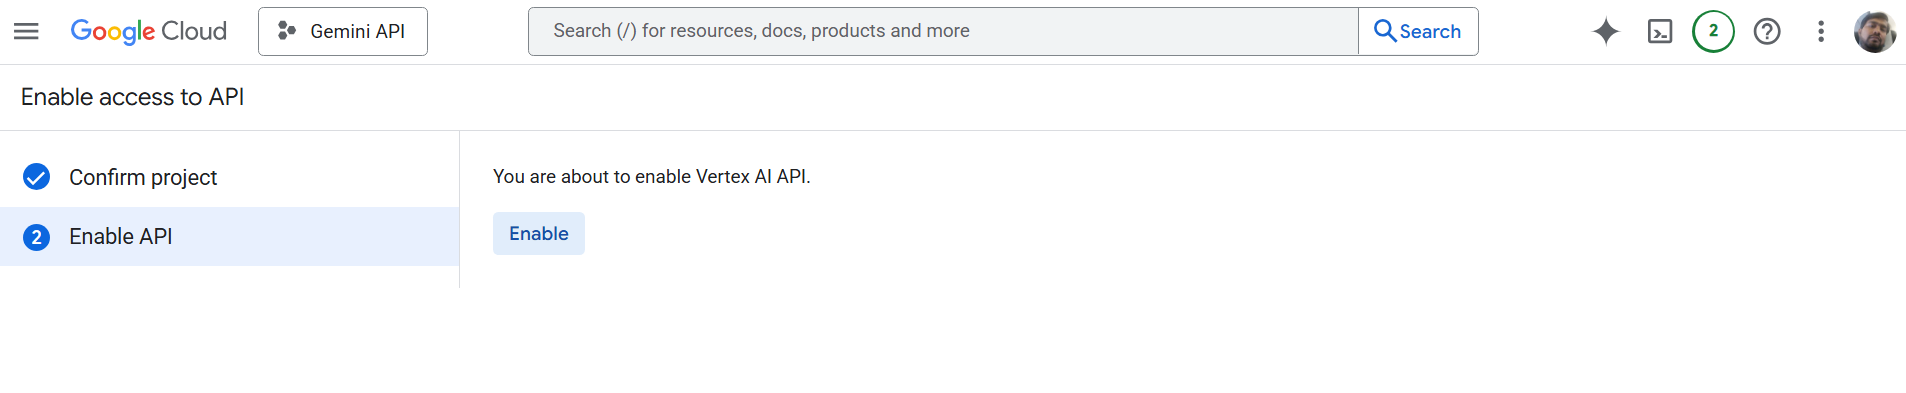 <br><br> 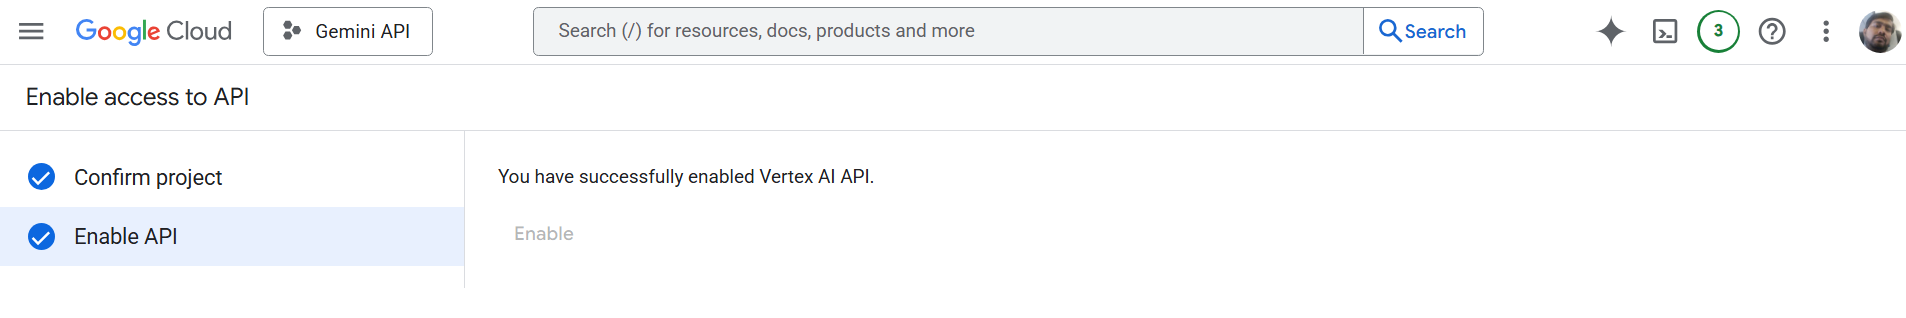 <br><br>
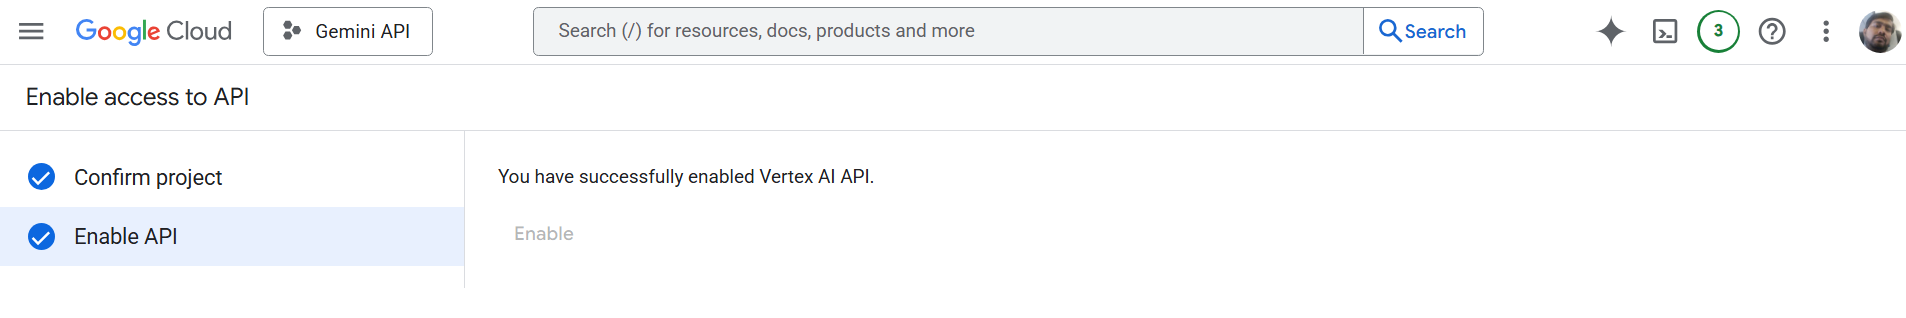

---

#### Method A: User Credentials (for Local Development)
1. **Install the gcloud CLI:** Follow the official [installation instructions](https://cloud.google.com/sdk/docs/install). <br><br>
    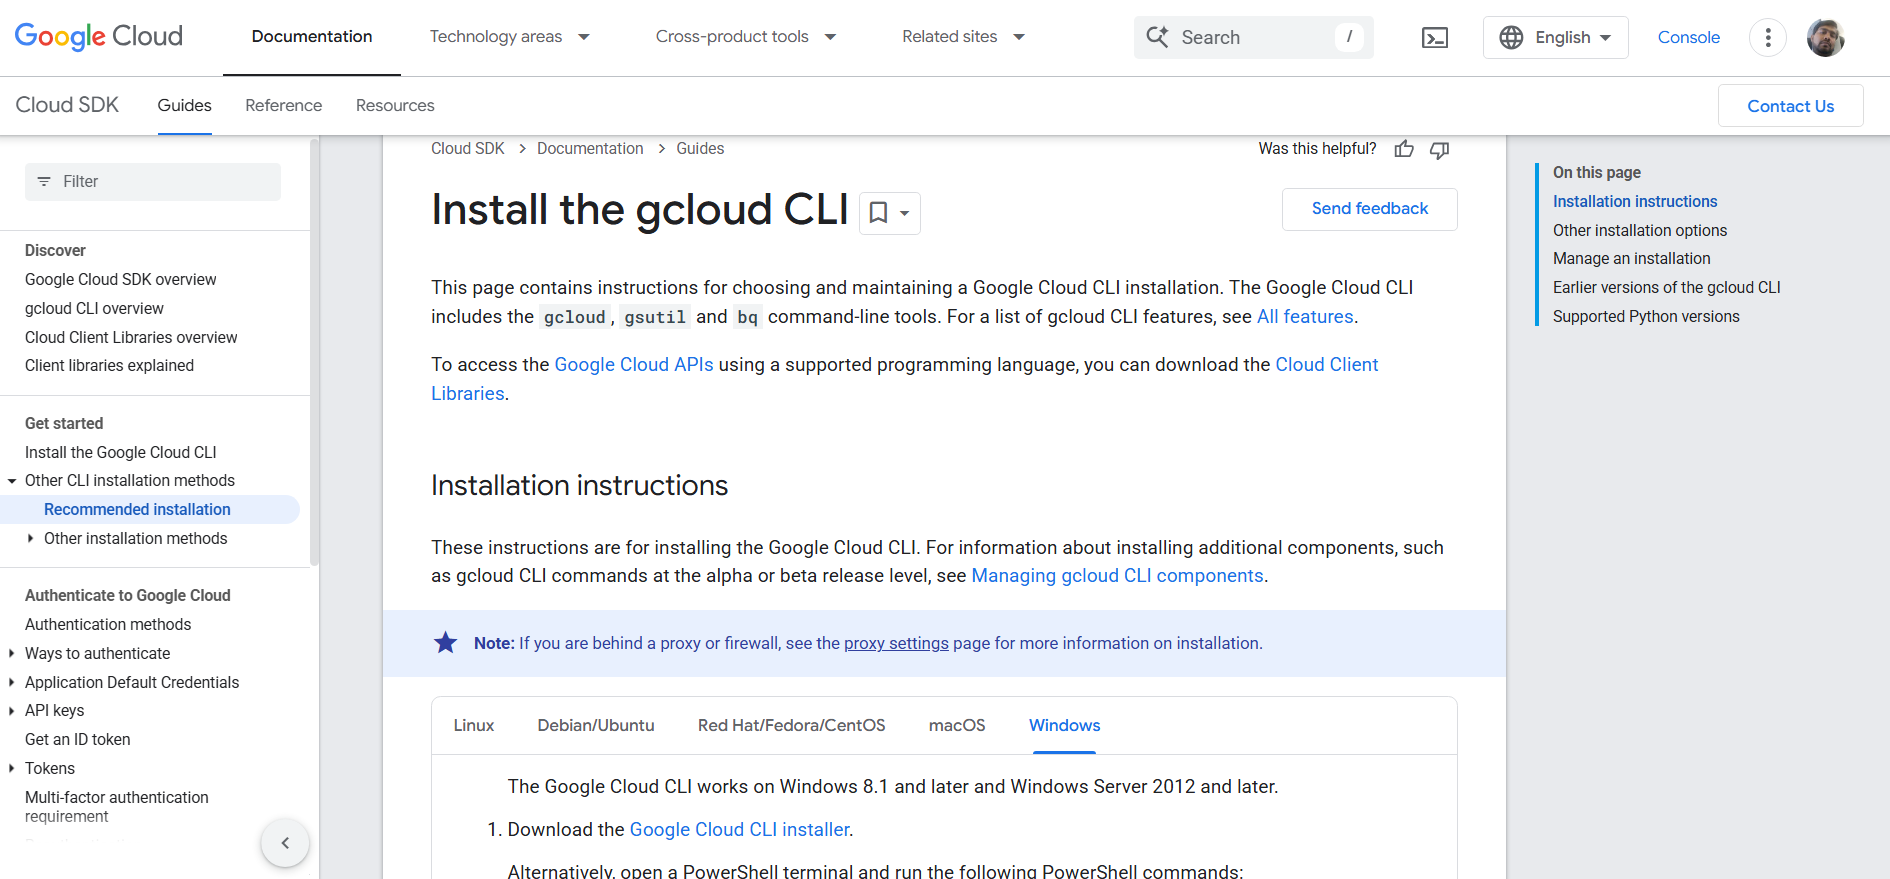 <br> 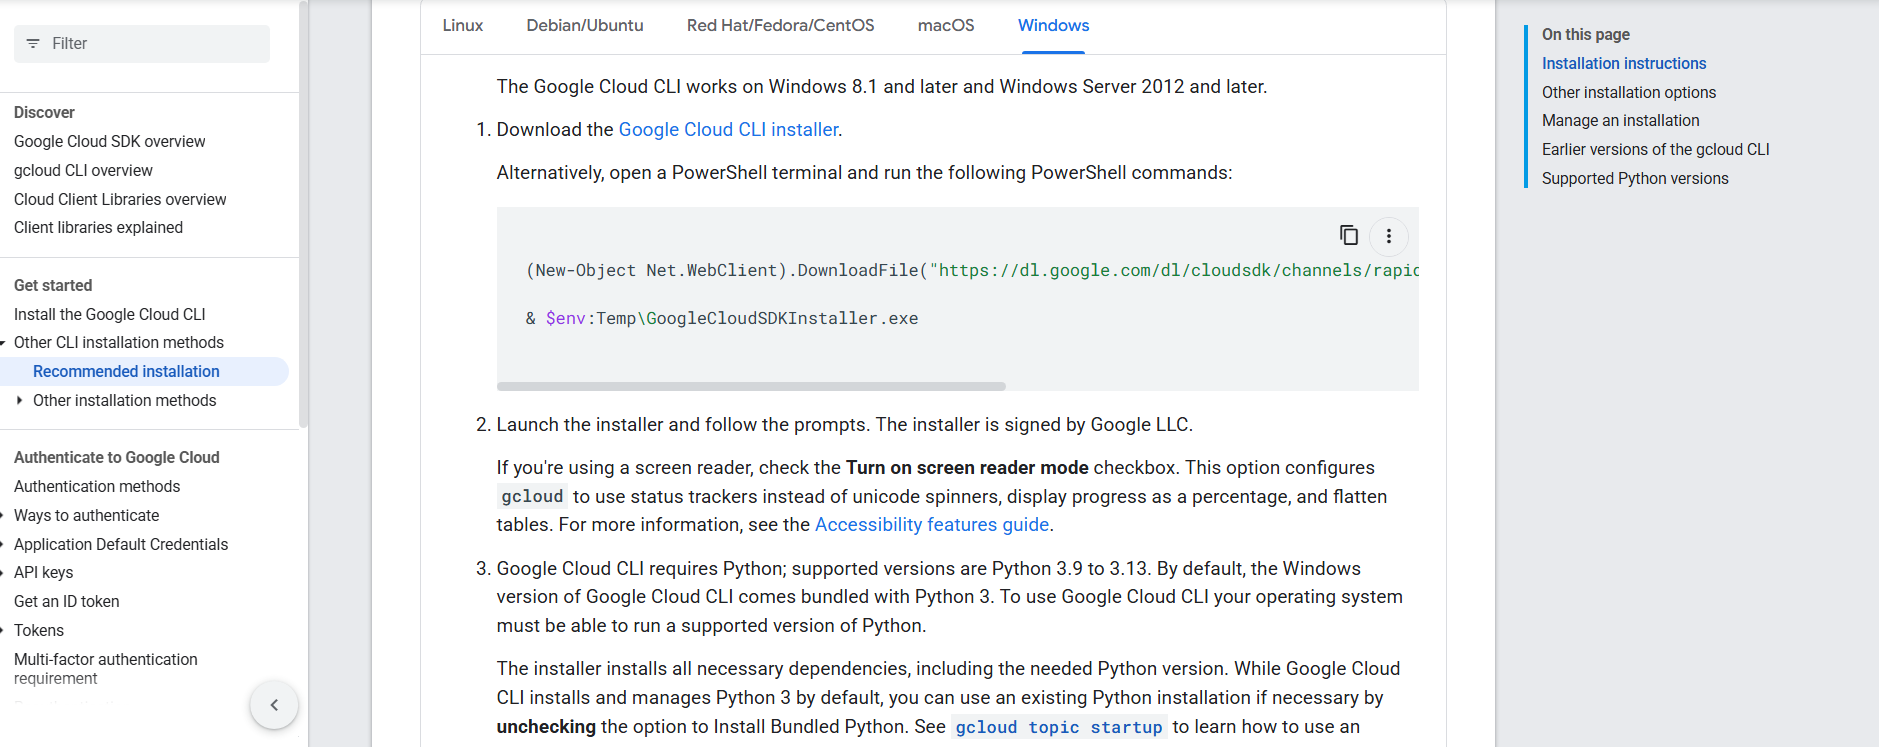

1. **Log in using ADC:** This command opens a browser to authenticate your user account for local development. <br>
    ```bash
    gcloud auth application-default login
    ```

1. **Set environment variables:** <br>
    ```bash
    export GOOGLE_CLOUD_PROJECT="YOUR_PROJECT_ID"
    export GOOGLE_CLOUD_LOCATION="YOUR_VERTEX_AI_LOCATION" # e.g., us-central1
    ```
    Explicitly tell the library to use Vertex AI:
    ```bash
    export GOOGLE_GENAI_USE_VERTEXAI=TRUE
    ```

1. **Models:** Find available model IDs in the [Vertex AI documentation](https://cloud.google.com/vertex-ai/generative-ai/docs/models). <br><br> 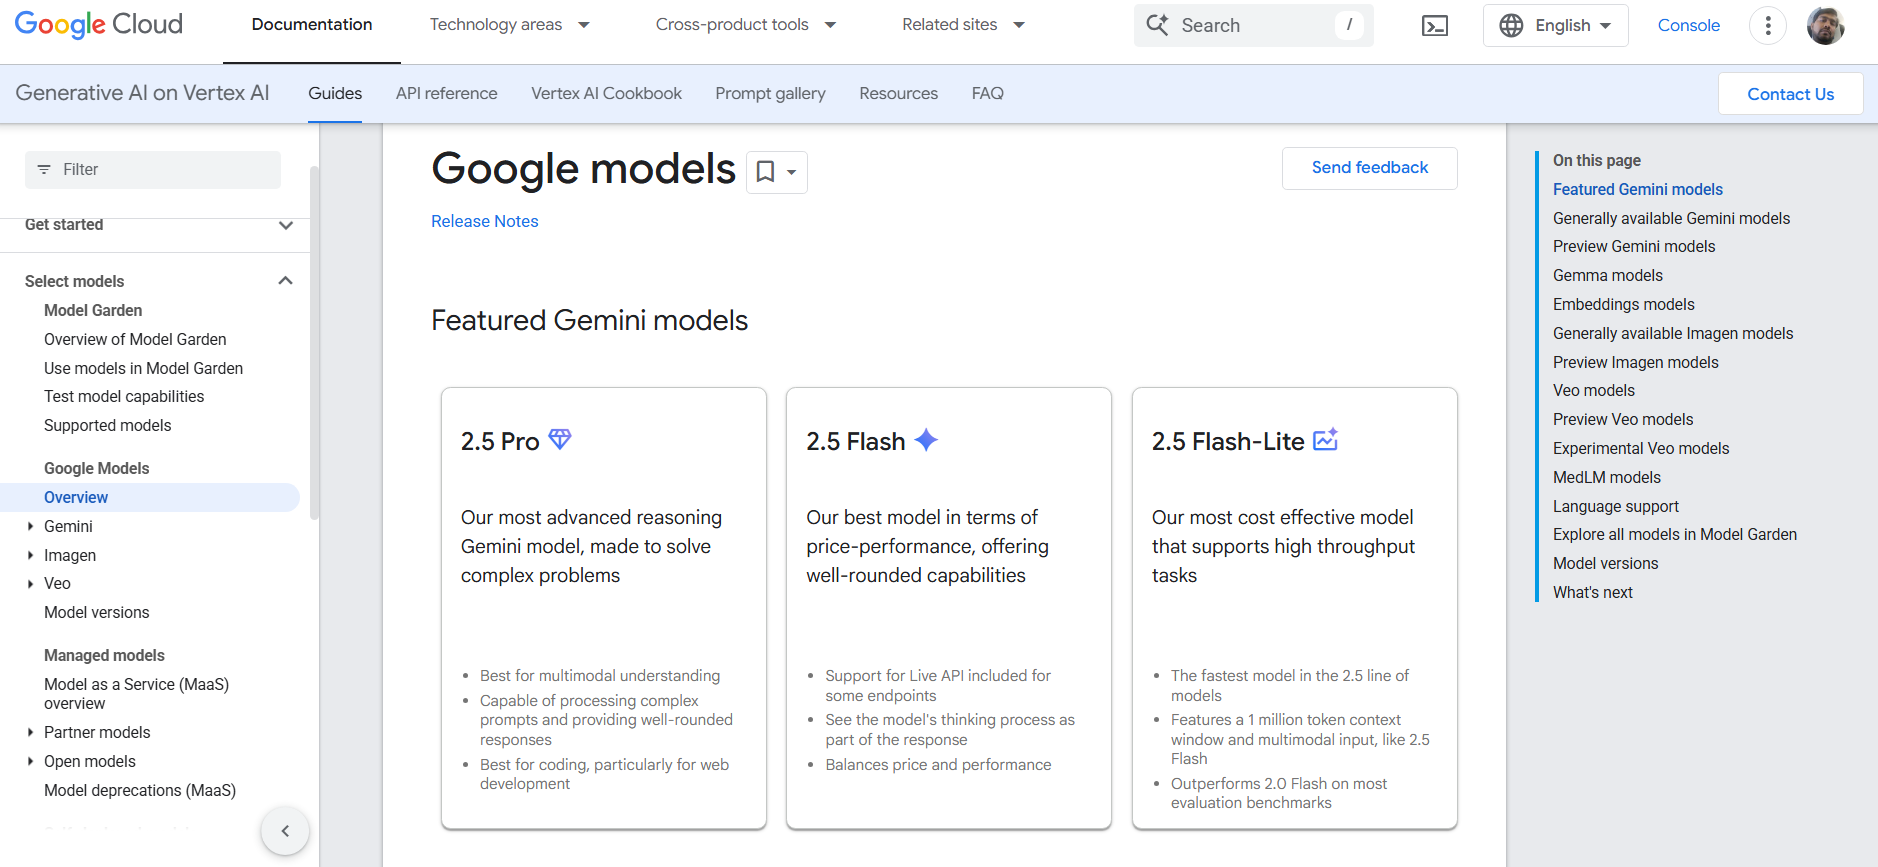

---

#### Method B: Vertex AI Express Mode
[Vertex AI Express Mode](https://cloud.google.com/vertex-ai/generative-ai/docs/start/express-mode/overview) offers a simplified, API-key-based setup for rapid prototyping. <br><br>
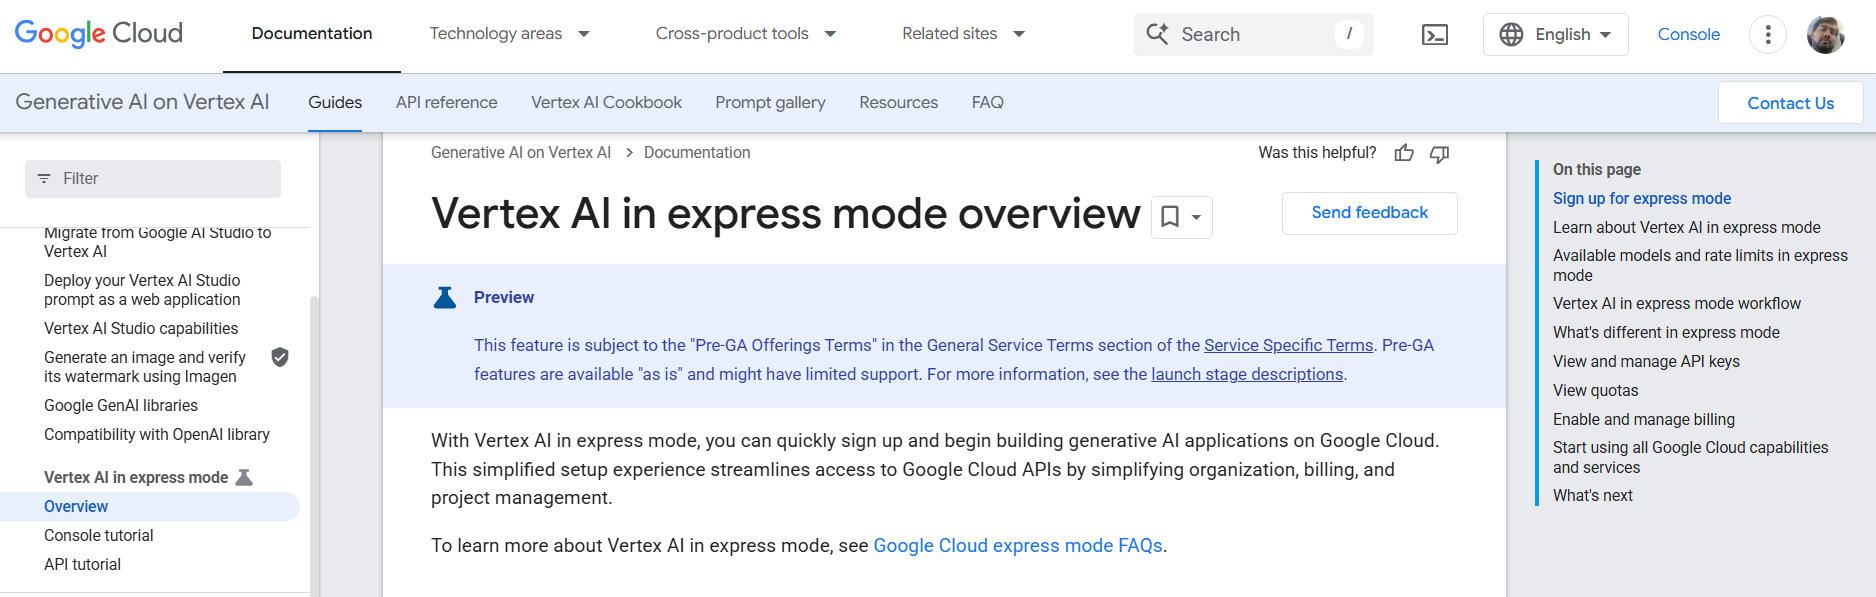 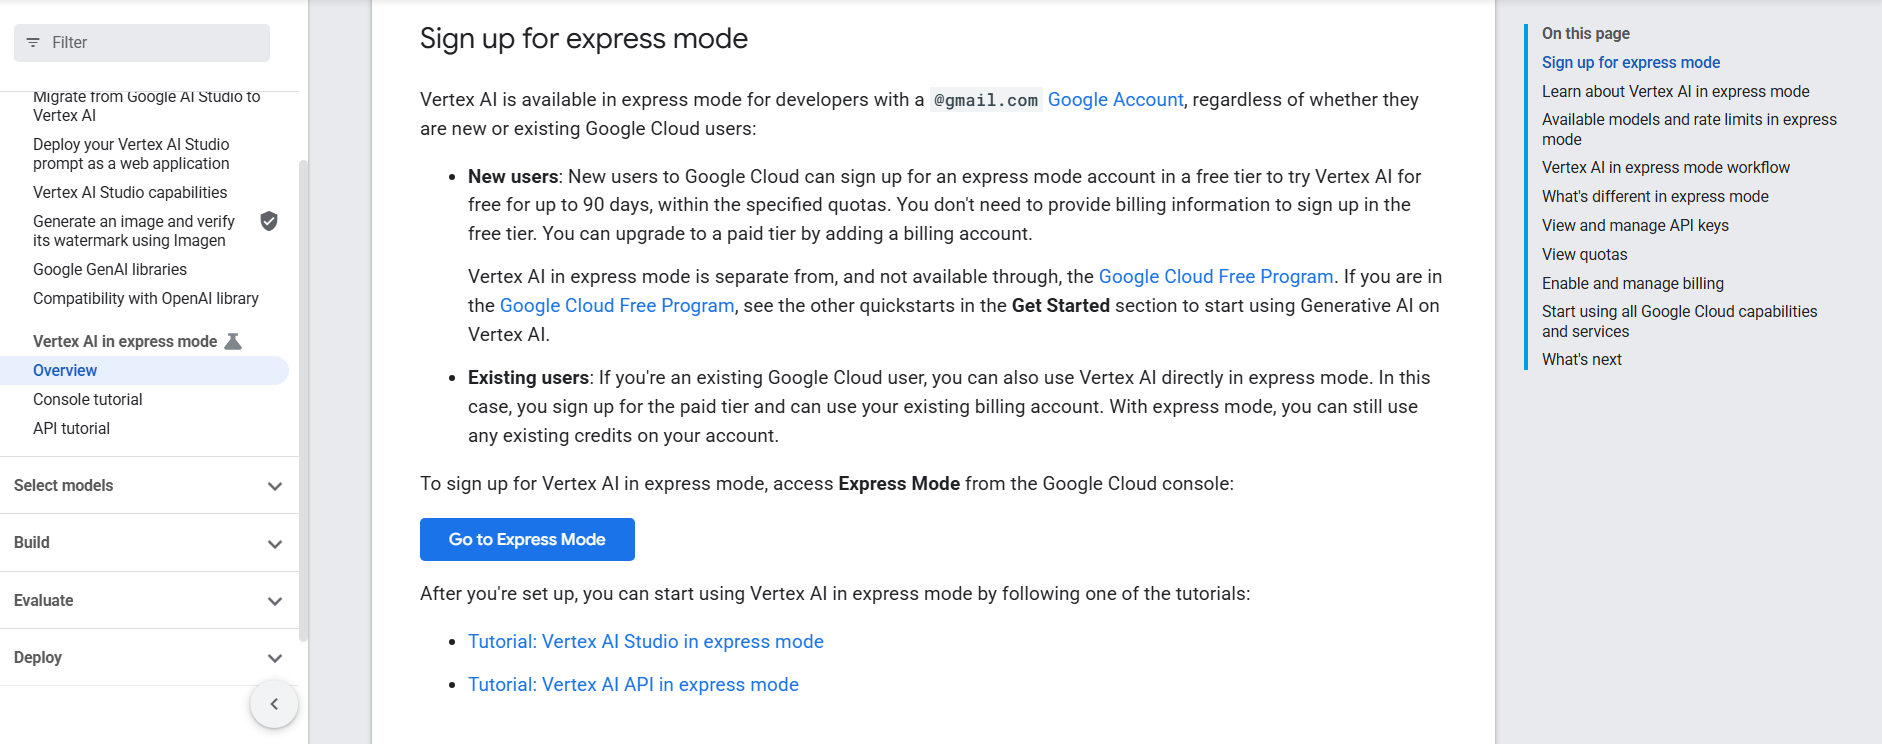

1. **Sign up for Express Mode** to get your API key.

1. **Set environment variables:**
    ```bash
    export GOOGLE_API_KEY="PASTE_YOUR_EXPRESS_MODE_API_KEY_HERE"
    export GOOGLE_GENAI_USE_VERTEXAI=TRUE
    ```

---
#### Method C: Service Account (for Production & Automation)
For deployed applications, a service account is the standard method.

1. Create a Service Account and grant it the Vertex AI User role.
1. Provide credentials to your application:
    - On Google Cloud: If you are running the agent in Cloud Run, GKE, VM or other Google Cloud services, the environment can automatically provide the service account credentials. You don't have to create a key file.

    - Elsewhere: Create a service account key file and point to it with an environment variable: <br>
        ```bash
        export GOOGLE_APPLICATION_CREDENTIALS="/path/to/your/keyfile.json"
        ```
    Instead of the key file, you can also authenticate the service account using Workload Identity. But this is outside the scope of this guide.

##### **Example:**
```Python
from google.adk.agents import LlmAgent

# --- Example using a stable Gemini Flash model ---
agent_gemini_flash = LlmAgent(
    # Use the latest stable Flash model identifier
    model="gemini-2.0-flash",
    name="gemini_flash_agent",
    instruction="You are a fast and helpful Gemini assistant.",
    # ... other agent parameters
)

# --- Example using a powerful Gemini Pro model ---
# Note: Always check the official Gemini documentation for the latest model names,
# including specific preview versions if needed. Preview models might have
# different availability or quota limitations.
agent_gemini_pro = LlmAgent(
    # Use the latest generally available Pro model identifier
    model="gemini-2.5-pro-preview-03-25",
    name="gemini_pro_agent",
    instruction="You are a powerful and knowledgeable Gemini assistant.",
    # ... other agent parameters
)
```

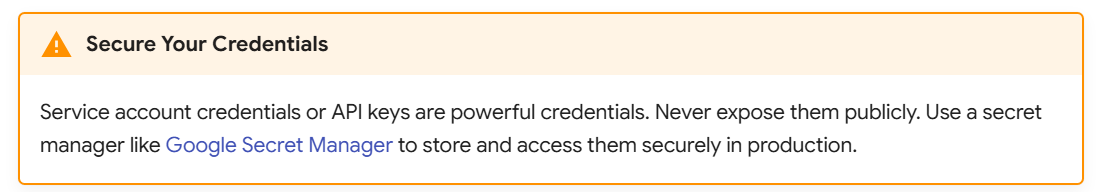

##### Google Secret Manager [Learn more](https://cloud.google.com/security/products/secret-manager?hl=en)
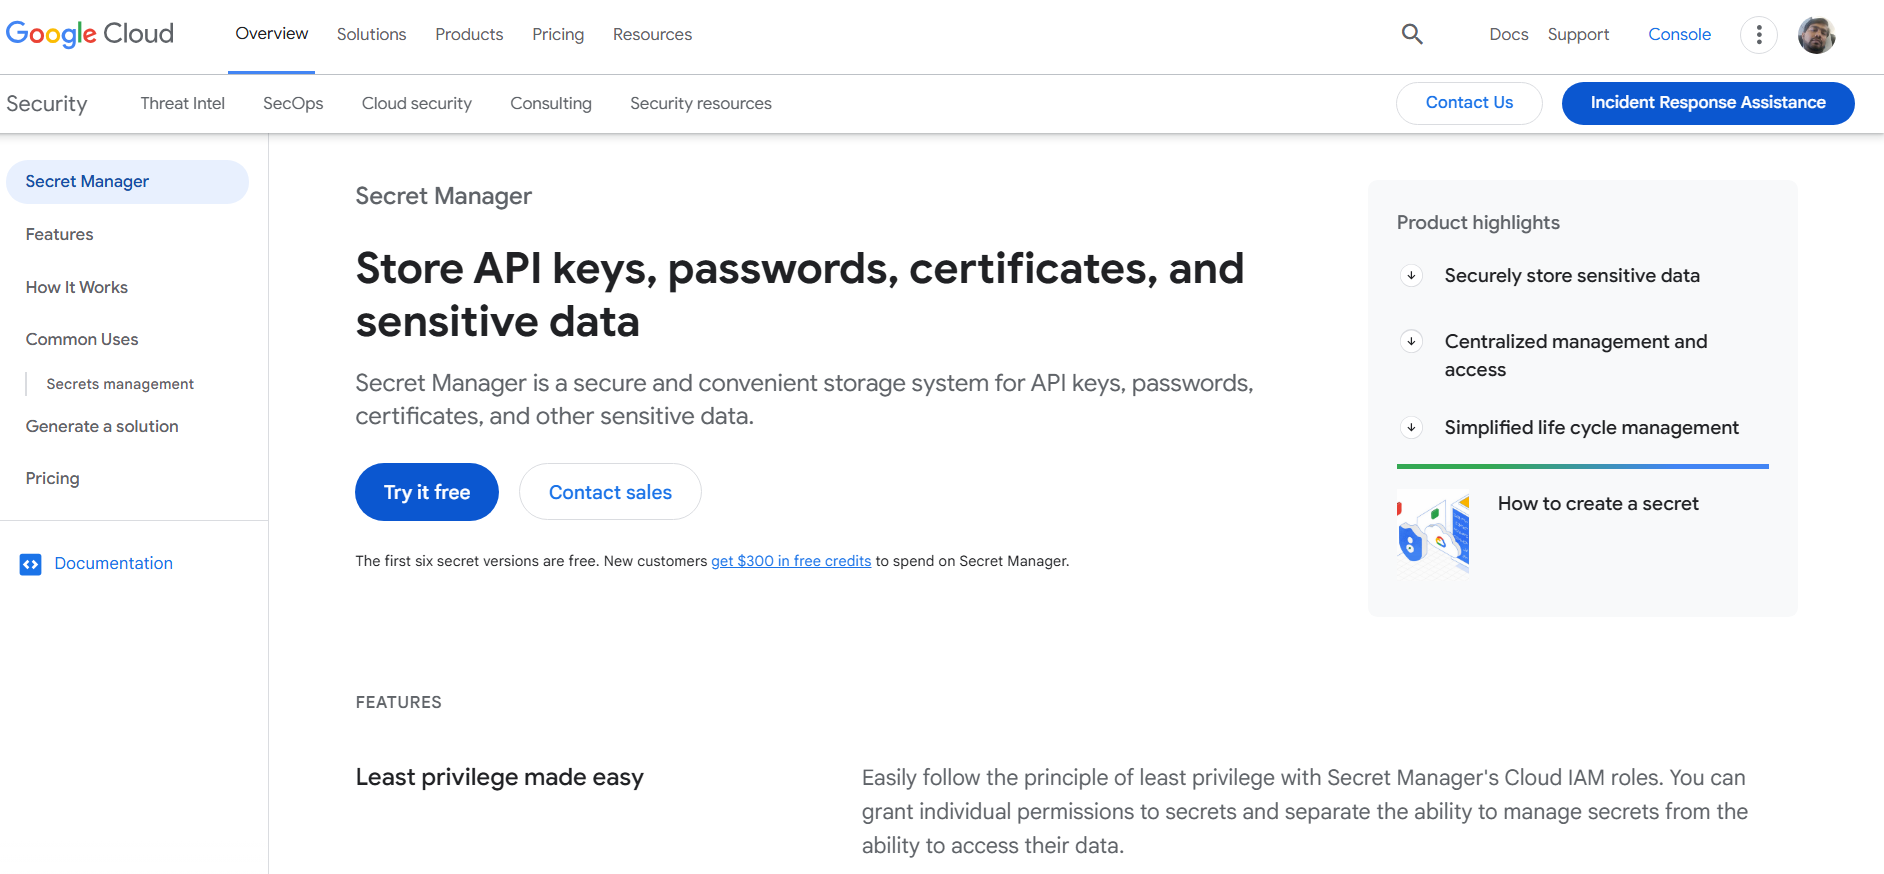 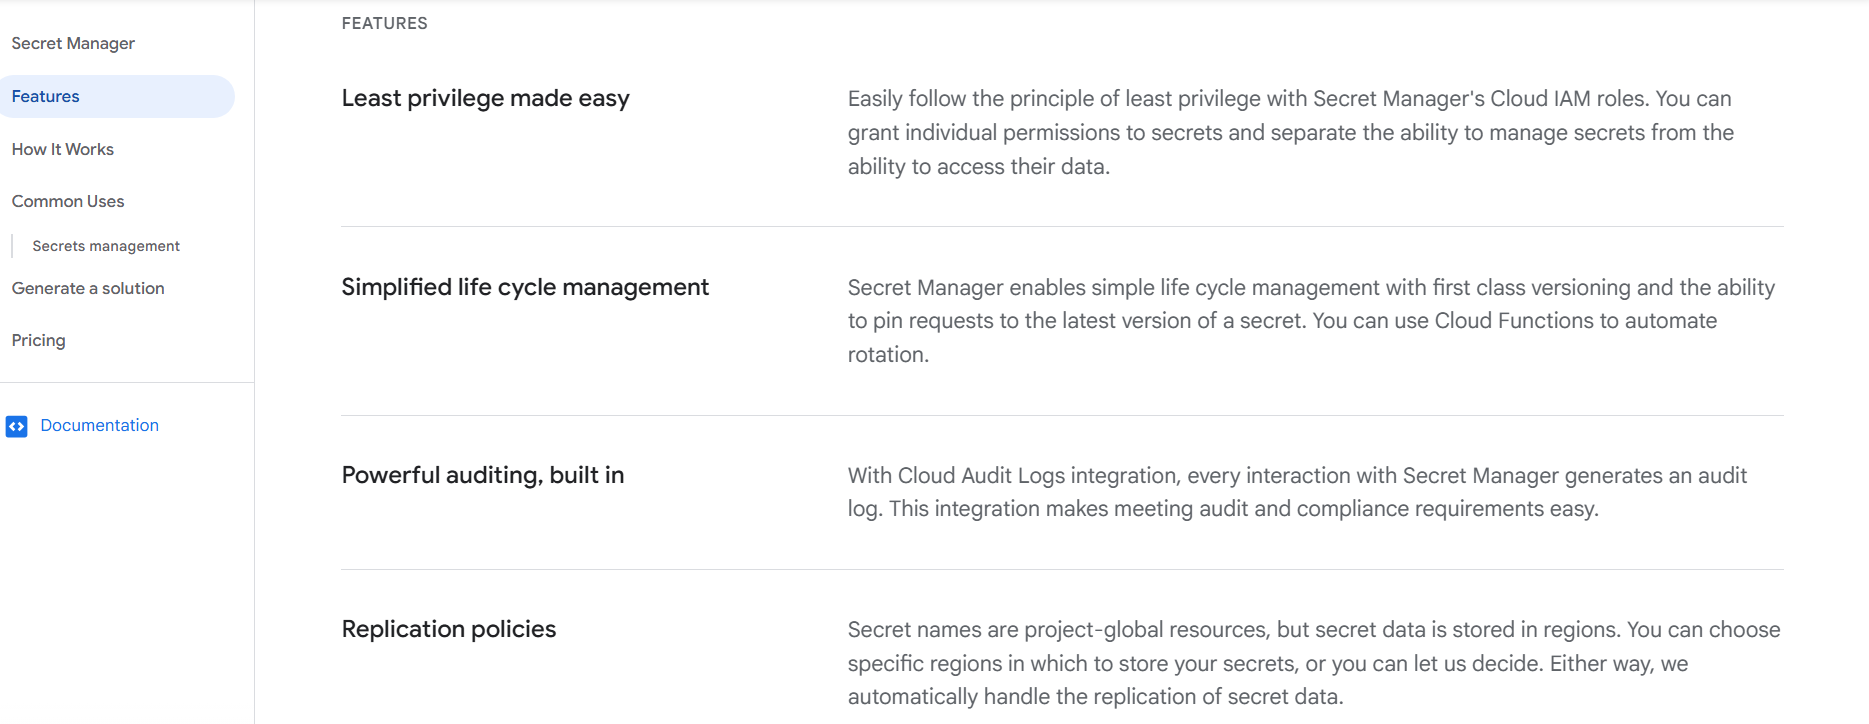 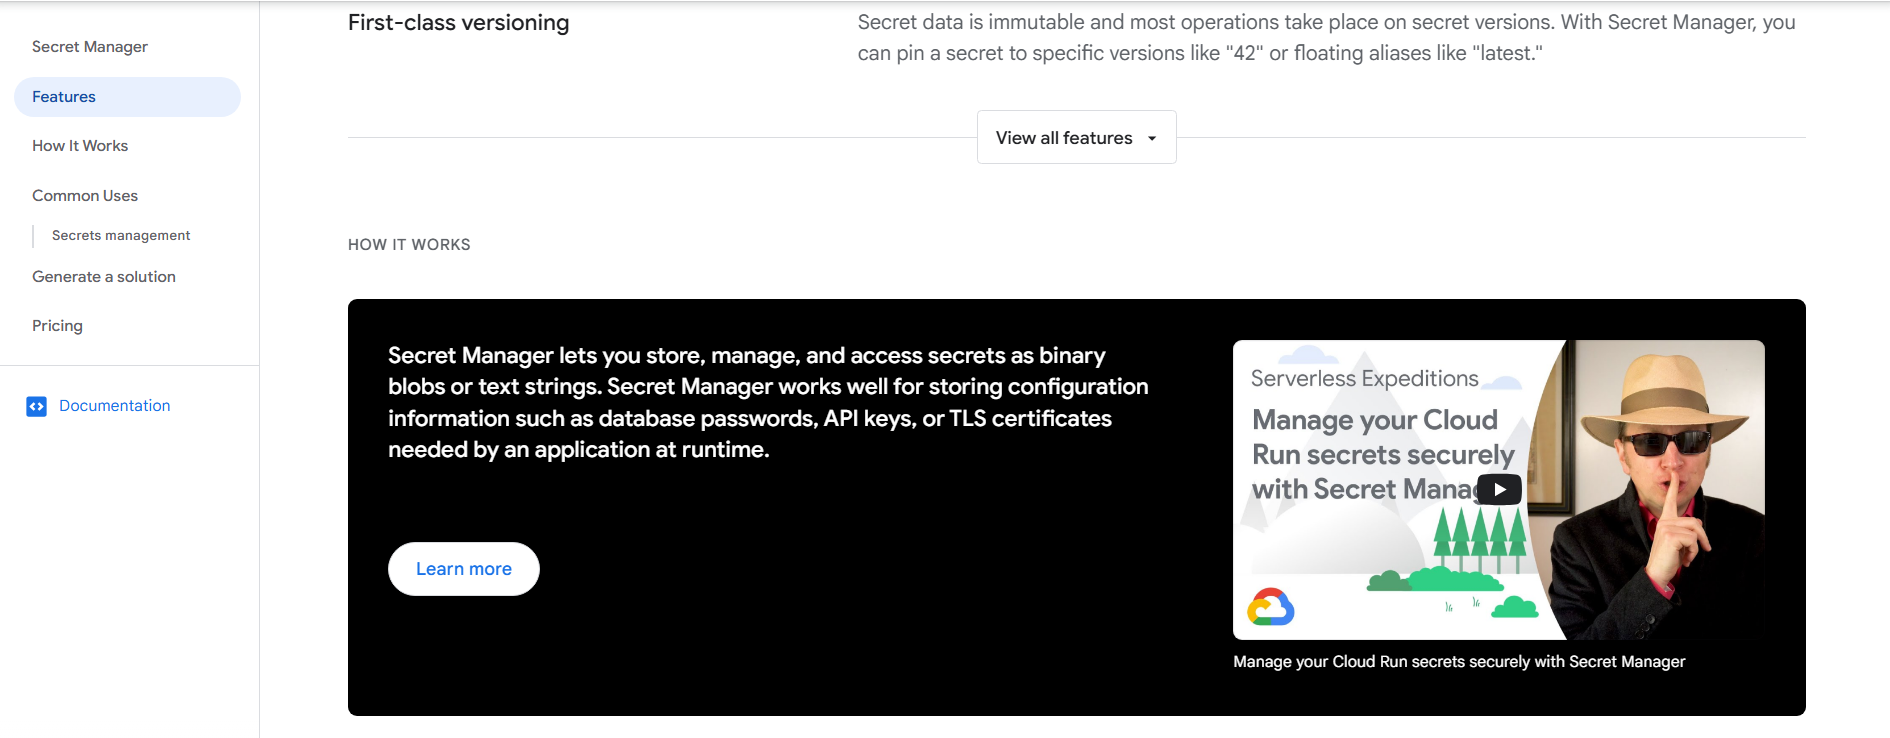
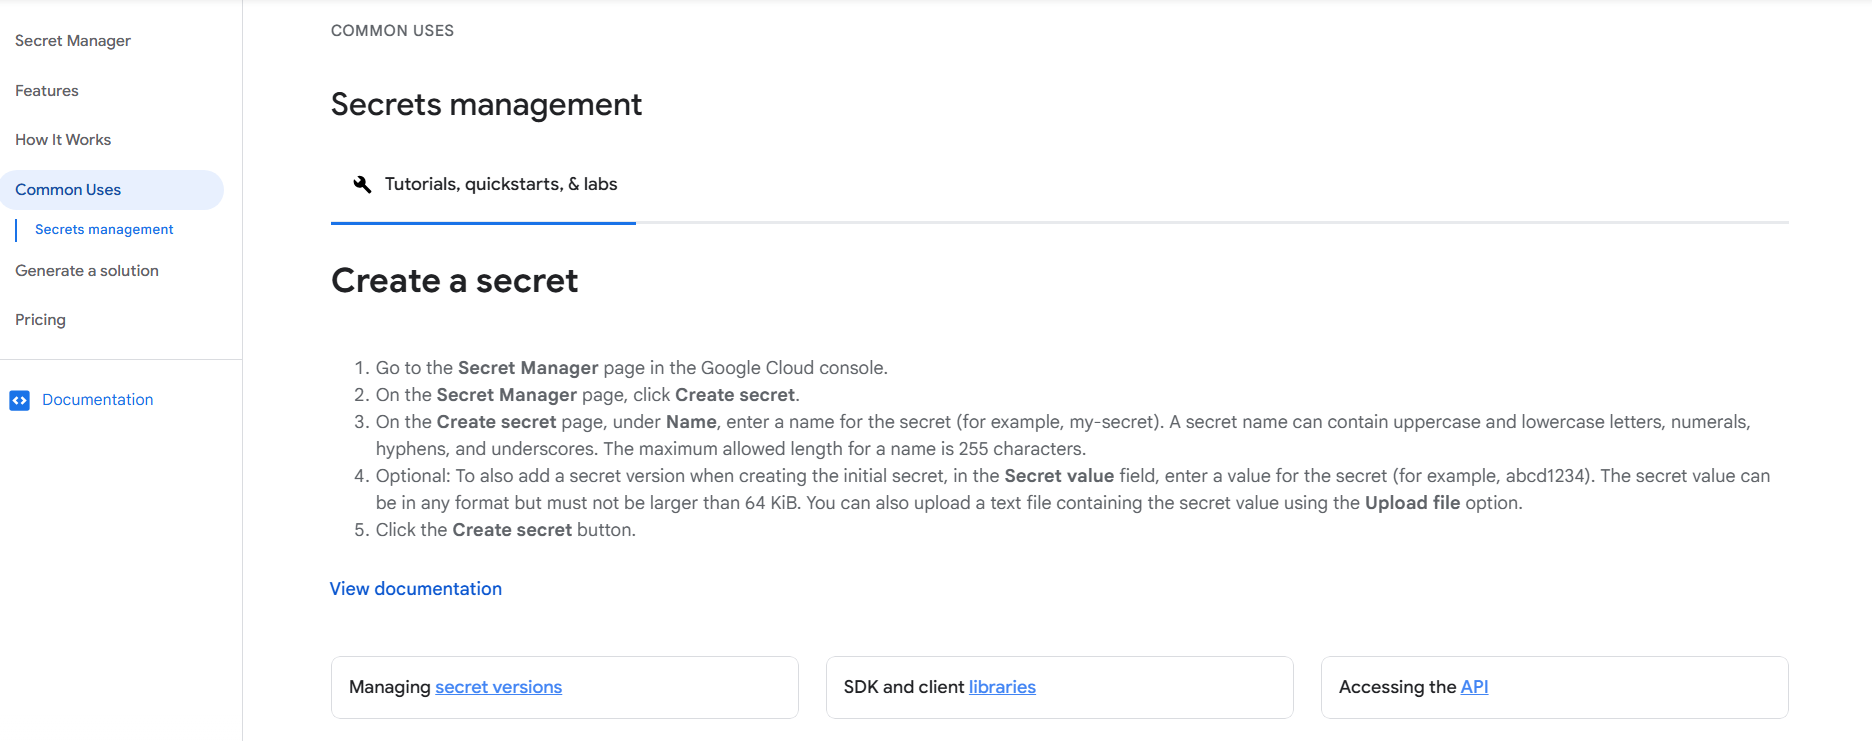 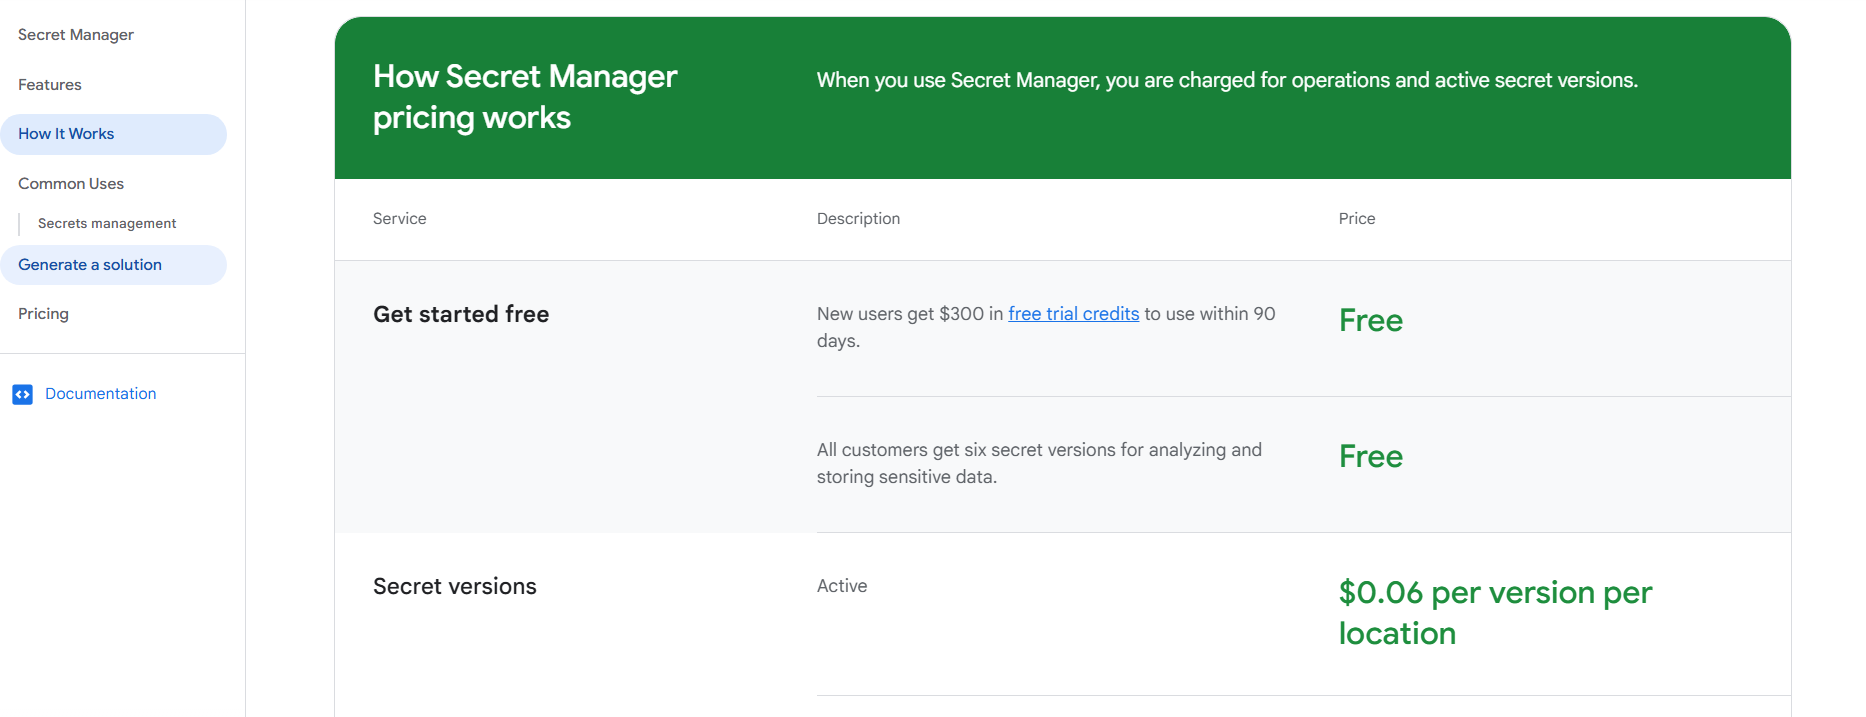 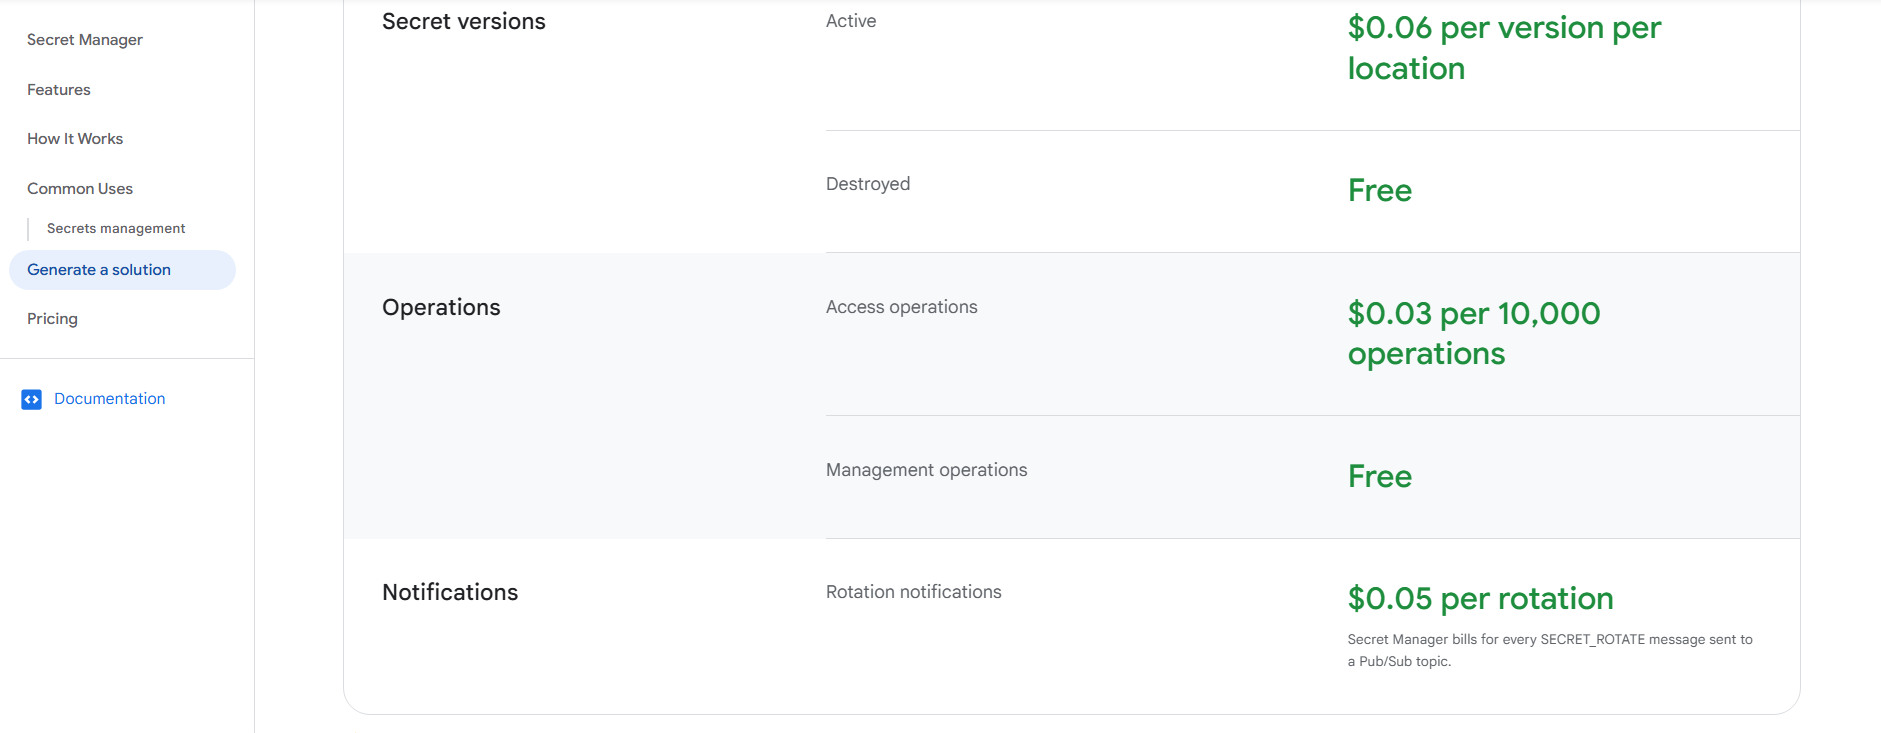
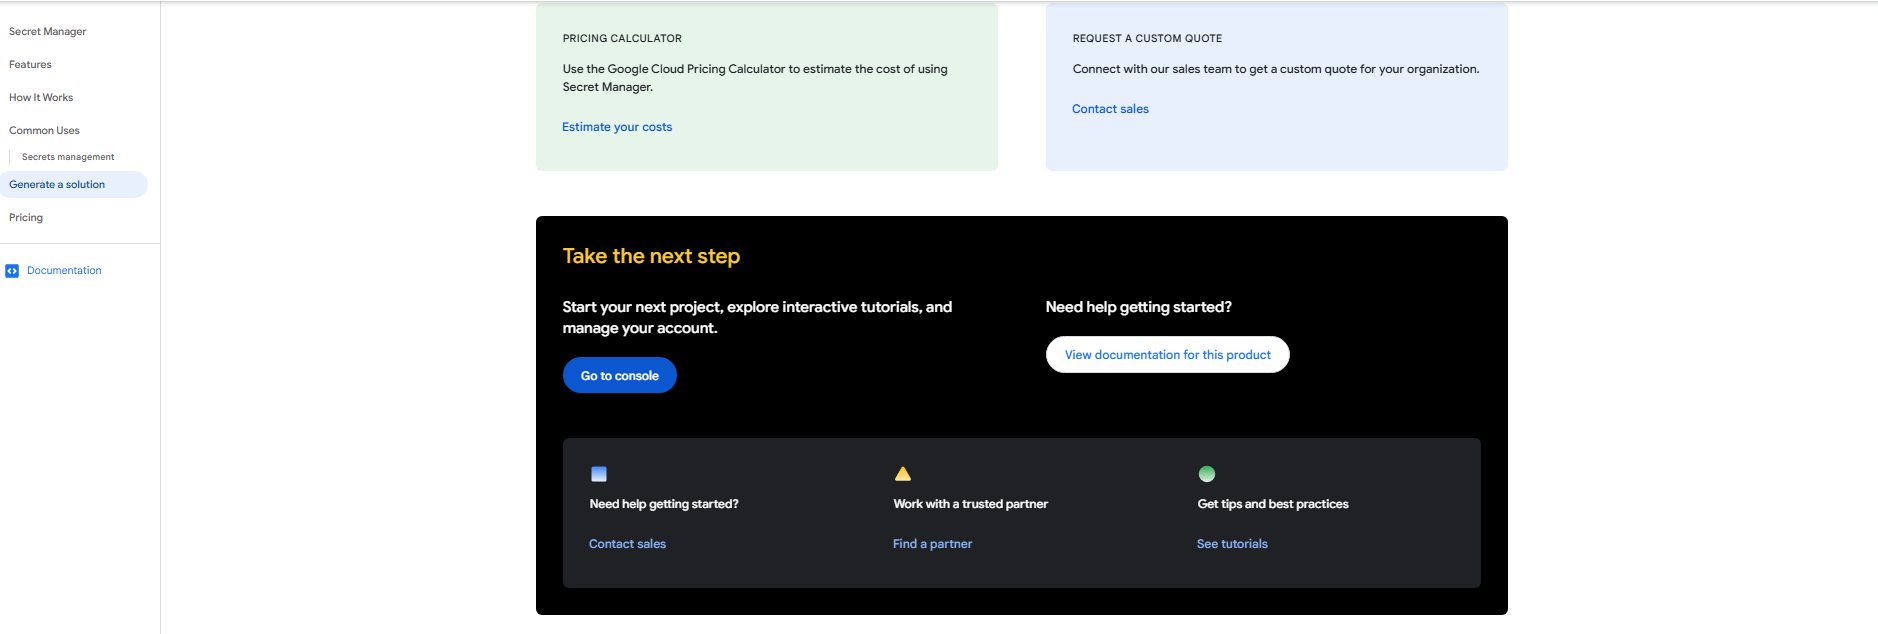

----